# **Installations**

In [2]:
!pip install -q supervision "ultralytics<=8.3.40"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.5/898.5 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 8.4 MB/s eta 0:00:00


In [3]:
# prevent ultralytics from tracking your activity
!yolo settings sync=False

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
JSONDict("/root/.config/Ultralytics/settings.json"):
{
  "settings_version": "0.0.6",
  "datasets_dir": "/content/datasets",
  "weights_dir": "weights",
  "runs_dir": "runs",
  "uuid": "569f3ba64b326db489132663f79cd37279811de477381b83ac131e6cdd129cbb",
  "sync": false,
  "api_key": "",
  "openai_api_key": "",
  "clearml": true,
  "comet": true,
  "dvc": true,
  "hub": true,
  "mlflow": true,
  "neptune": true,
  "raytune": true,
  "tensorboard": true,
  "wandb": false,
  "vscode_msg": true
}
💡 Learn more about Ultralytics Settings at https://docs.ultralytics.com/quickstart/#ultralytics-settings


In [4]:
import cv2
import numpy as np
import supervision as sv

from tqdm import tqdm
from ultralytics import YOLO
from collections import defaultdict, deque

In [5]:
SOURCE_VIDEO_PATH = "5382495-uhd_3840_2160_24fps.mp4"
TARGET_VIDEO_PATH = "dashcam-detections-result.mp4"

MODEL_NAME = "yolov8l.pt"
MODEL_RESOLUTION = 1280

CONFIDENCE_THRESHOLD = 0.3
IOU_THRESHOLD = 0.5

In [6]:
model = YOLO(MODEL_NAME)

video_info = sv.VideoInfo.from_video_path(video_path=SOURCE_VIDEO_PATH)
frame_generator = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH)

print(video_info)

100%|██████████| 83.7M/83.7M [00:02<00:00, 36.8MB/s]


VideoInfo(width=3840, height=2160, fps=24.0, total_frames=818)


In [8]:
frame = next(iter(frame_generator))

result = model(frame, imgsz=MODEL_RESOLUTION, verbose=False)[0]
detections = sv.Detections.from_ultralytics(result)

print(detections)

Detections(xyxy=array([[     642.84,      582.22,      802.99,      648.39],
       [     2006.6,       495.9,      2050.9,      531.64],
       [     1847.9,      497.32,      1927.1,      563.79],
       [     957.57,      1187.9,      2971.6,        1500],
       [     2037.6,      491.75,      2074.5,      526.81]], dtype=float32), mask=None, confidence=array([    0.83471,     0.83463,     0.82592,     0.63783,     0.53444], dtype=float32), class_id=array([2, 2, 2, 2, 2]), tracker_id=None, data={'class_name': array(['car', 'car', 'car', 'car', 'car'], dtype='<U3')}, metadata={})


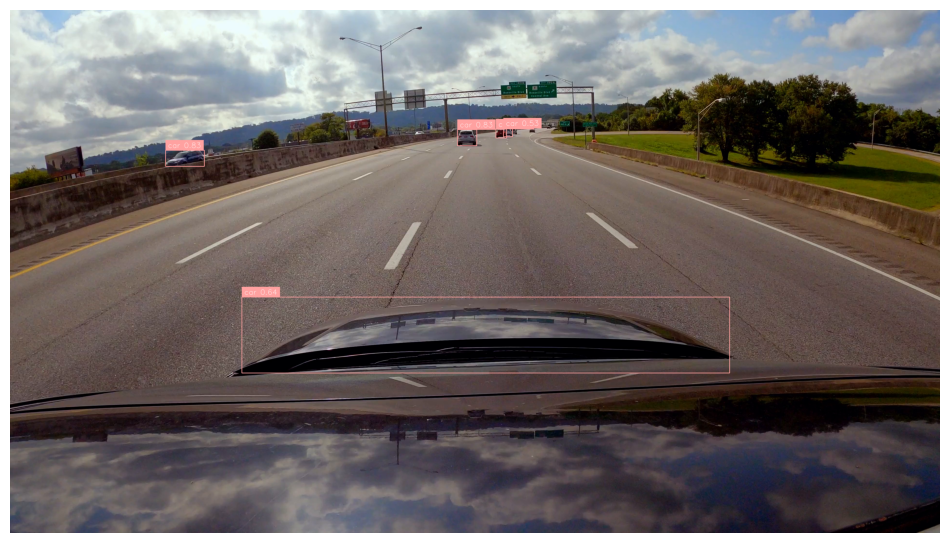

In [ ]:
annotated_frame = frame.copy()

box_annotator = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_scale=1, text_thickness=1)

labels = [
    f"{class_name} {confidence:.2f}"
    for class_name, confidence
    in zip(detections['class_name'], detections.confidence)
]

annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)
annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections, labels=labels)

sv.plot_image(annotated_frame)

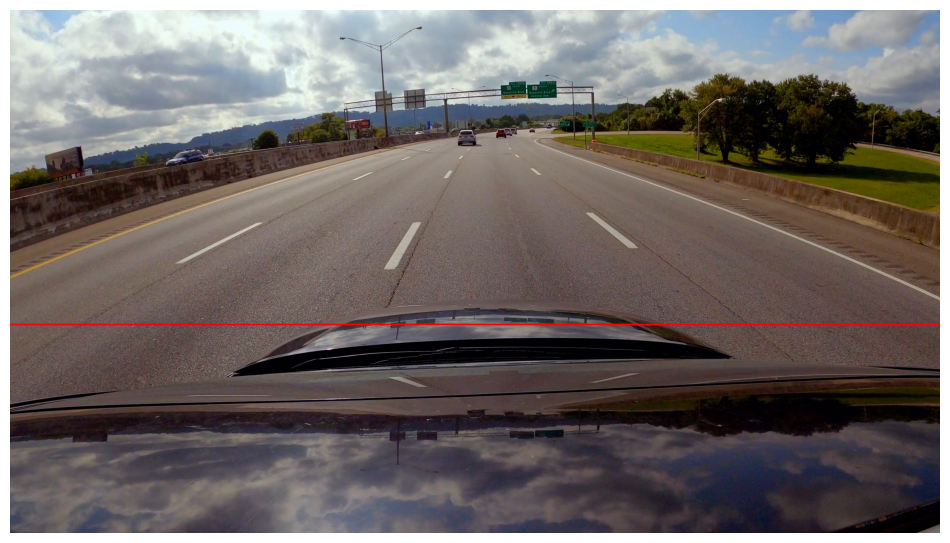

In [9]:
HOOD_Y_START = 1300  # our first guess, we'll adjust

annotated_frame = frame.copy()
cv2.line(annotated_frame, (0, HOOD_Y_START), (frame.shape[1], HOOD_Y_START), (0, 0, 255), thickness=6)
sv.plot_image(annotated_frame)

**Tracking And Detection**

In [10]:
byte_track = sv.ByteTrack(
    frame_rate=video_info.fps, track_activation_threshold=CONFIDENCE_THRESHOLD
)

thickness = sv.calculate_optimal_line_thickness(resolution_wh=video_info.resolution_wh)
text_scale = sv.calculate_optimal_text_scale(resolution_wh=video_info.resolution_wh)

box_annotator = sv.BoxAnnotator(thickness=thickness)
label_annotator = sv.LabelAnnotator(
    text_scale=text_scale,
    text_thickness=thickness,
    text_position=sv.Position.BOTTOM_CENTER
)
trace_annotator = sv.TraceAnnotator(
    thickness=thickness,
    trace_length=int(video_info.fps * 2),
    position=sv.Position.BOTTOM_CENTER
)

VEHICLE_CLASS_IDS = [2, 3, 5, 7]
HOOD_Y_START = 1300

frame_generator = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH)

with sv.VideoSink(TARGET_VIDEO_PATH, video_info) as sink:

    for frame in tqdm(frame_generator, total=video_info.total_frames):

        result = model(frame, imgsz=MODEL_RESOLUTION, verbose=False)[0]
        detections = sv.Detections.from_ultralytics(result)

        detections = detections[detections.confidence > CONFIDENCE_THRESHOLD]
        detections = detections[np.isin(detections.class_id, VEHICLE_CLASS_IDS)]
        detections = detections[detections.xyxy[:, 3] < HOOD_Y_START]  # exclude own hood

        detections = detections.with_nms(IOU_THRESHOLD)
        detections = byte_track.update_with_detections(detections=detections)

        labels = [f"#{tracker_id} {class_name}" for tracker_id, class_name in zip(detections.tracker_id, detections['class_name'])]

        annotated_frame = frame.copy()
        annotated_frame = trace_annotator.annotate(scene=annotated_frame, detections=detections)
        annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)
        annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections, labels=labels)

        sink.write_frame(annotated_frame)

100%|██████████| 818/818 [02:55<00:00,  4.67it/s]


In [11]:
import math

FRAME_WIDTH = video_info.width  # 3840
ASSUMED_HORIZONTAL_FOV_DEG = 100  # typical dashcam wide-angle lens, adjust if you know the real spec

focal_length_px = (FRAME_WIDTH / 2) / math.tan(math.radians(ASSUMED_HORIZONTAL_FOV_DEG / 2))
print(f"Estimated focal length: {focal_length_px:.1f} px")

Estimated focal length: 1611.1 px


In [12]:
REAL_CAR_WIDTH_M = 1.8  # average car width in meters

def estimate_distance(box_width_px, focal_length_px, real_width_m=REAL_CAR_WIDTH_M):
    if box_width_px <= 0:
        return None
    return (real_width_m * focal_length_px) / box_width_px

In [13]:
box_widths = detections.xyxy[:, 2] - detections.xyxy[:, 0]  # x2 - x1
distances = [estimate_distance(w, focal_length_px) for w in box_widths]

for tracker_id, dist in zip(detections.tracker_id, distances):
    print(f"#{tracker_id}: {dist:.1f} m")

#18: 17.1 m
#66: 95.3 m
#47: 49.8 m
#103: 136.7 m


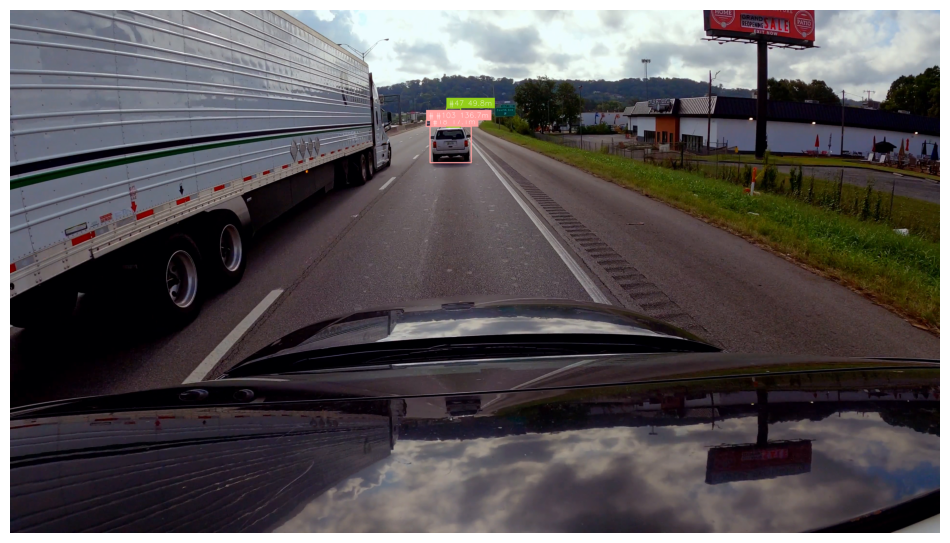

In [ ]:
labels = [f"#{tid} {d:.1f}m" for tid, d in zip(detections.tracker_id, distances)]

annotated_frame = frame.copy()
annotated_frame = sv.BoxAnnotator(thickness=3).annotate(scene=annotated_frame, detections=detections)
annotated_frame = sv.LabelAnnotator(text_scale=1).annotate(scene=annotated_frame, detections=detections, labels=labels)

sv.plot_image(annotated_frame)

**Tracking + Detection + Distance Estimation**

In [14]:
byte_track = sv.ByteTrack(
    frame_rate=video_info.fps, track_activation_threshold=CONFIDENCE_THRESHOLD
)

thickness = sv.calculate_optimal_line_thickness(resolution_wh=video_info.resolution_wh)
text_scale = sv.calculate_optimal_text_scale(resolution_wh=video_info.resolution_wh)

box_annotator = sv.BoxAnnotator(thickness=thickness)
label_annotator = sv.LabelAnnotator(
    text_scale=text_scale,
    text_thickness=thickness,
    text_position=sv.Position.BOTTOM_CENTER
)
trace_annotator = sv.TraceAnnotator(
    thickness=thickness,
    trace_length=int(video_info.fps * 2),
    position=sv.Position.BOTTOM_CENTER
)

VEHICLE_CLASS_IDS = [2, 3, 5, 7]
HOOD_Y_START = 1300

TARGET_VIDEO_PATH_DISTANCE = "dashcam-distance-result.mp4"

frame_generator = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH)

with sv.VideoSink(TARGET_VIDEO_PATH_DISTANCE, video_info) as sink:

    for frame in tqdm(frame_generator, total=video_info.total_frames):

        result = model(frame, imgsz=MODEL_RESOLUTION, verbose=False)[0]
        detections = sv.Detections.from_ultralytics(result)

        detections = detections[detections.confidence > CONFIDENCE_THRESHOLD]
        detections = detections[np.isin(detections.class_id, VEHICLE_CLASS_IDS)]
        detections = detections[detections.xyxy[:, 3] < HOOD_Y_START]
        detections = detections.with_nms(IOU_THRESHOLD)
        detections = byte_track.update_with_detections(detections=detections)

        # distance estimation
        box_widths = detections.xyxy[:, 2] - detections.xyxy[:, 0]
        distances = [estimate_distance(w, focal_length_px) for w in box_widths]

        labels = [
            f"#{tid} {dist:.1f}m" if dist is not None else f"#{tid}"
            for tid, dist in zip(detections.tracker_id, distances)
        ]

        annotated_frame = frame.copy()
        annotated_frame = trace_annotator.annotate(scene=annotated_frame, detections=detections)
        annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)
        annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections, labels=labels)

        sink.write_frame(annotated_frame)

100%|██████████| 818/818 [02:54<00:00,  4.70it/s]


**Lane Detection**

In [15]:
!git clone https://github.com/ibaiGorordo/Ultrafast-Lane-Detection-Inference-Pytorch-.git
%cd Ultrafast-Lane-Detection-Inference-Pytorch-
!pip install -q -r requirements.txt

Cloning into 'Ultrafast-Lane-Detection-Inference-Pytorch-'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 63 (delta 24), reused 39 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 10.88 MiB | 15.75 MiB/s, done.
Resolving deltas: 100% (24/24), done.
/content/Ultrafast-Lane-Detection-Inference-Pytorch-
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [16]:
!pip install -q opencv-python scipy

In [17]:
import sys
sys.path.append('/content/ufld/Ultrafast-Lane-Detection-Inference-Pytorch-')

from ultrafastLaneDetector import UltrafastLaneDetector, ModelType

In [18]:
!mkdir -p models
!gdown --id 1WCYyur5ZaWczH15ecmeDowrW30xcLrCn -O models/tusimple_18.pth

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1WCYyur5ZaWczH15ecmeDowrW30xcLrCn
From (redirected): https://drive.google.com/uc?id=1WCYyur5ZaWczH15ecmeDowrW30xcLrCn&confirm=t&uuid=4caef2c8-00de-457c-aef7-25690a0aca65
To: /content/Ultrafast-Lane-Detection-Inference-Pytorch-/models/tusimple_18.pth
100% 245M/245M [00:03<00:00, 72.0MB/s]


In [19]:
lane_detector_ufld = UltrafastLaneDetector("models/tusimple_18.pth", ModelType.TUSIMPLE, use_gpu=True)

In [20]:
!sed -i 's/return np.array(lanes_points), np.array(lanes_detected)/return np.array(lanes_points, dtype=object), np.array(lanes_detected)/' /content/Ultrafast-Lane-Detection-Inference-Pytorch-/ultrafastLaneDetector/ultrafastLaneDetector.py

In [21]:
!grep -n "np.array(lanes_points" /content/Ultrafast-Lane-Detection-Inference-Pytorch-/ultrafastLaneDetector/ultrafastLaneDetector.py

179:		return np.array(lanes_points, dtype=object), np.array(lanes_detected)


In [22]:
import importlib
import ultrafastLaneDetector
importlib.reload(ultrafastLaneDetector)

from ultrafastLaneDetector import UltrafastLaneDetector, ModelType

lane_detector_ufld = UltrafastLaneDetector("models/tusimple_18.pth", ModelType.TUSIMPLE, use_gpu=True)

In [ ]:
import ultrafastLaneDetector
print(ultrafastLaneDetector.__file__)

/content/Ultrafast-Lane-Detection-Inference-Pytorch-/ultrafastLaneDetector/__init__.py


In [1]:
# After restarting runtime
# re-import everything you need
import cv2
import numpy as np
import supervision as sv
import torch
import sys

sys.path.append('/content/Ultrafast-Lane-Detection-Inference-Pytorch-')

from ultrafastLaneDetector import UltrafastLaneDetector, ModelType

In [ ]:
from google.colab import files
uploaded = files.upload()

video_path = list(uploaded.keys())[0]

Saving 5382495-uhd_3840_2160_24fps.mp4 to 5382495-uhd_3840_2160_24fps (1).mp4


In [2]:
# reload the video and grab your test frame again
SOURCE_VIDEO_PATH = "5382495-uhd_3840_2160_24fps.mp4"  # your filename

frame_generator = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH)
frame = next(frame_generator)

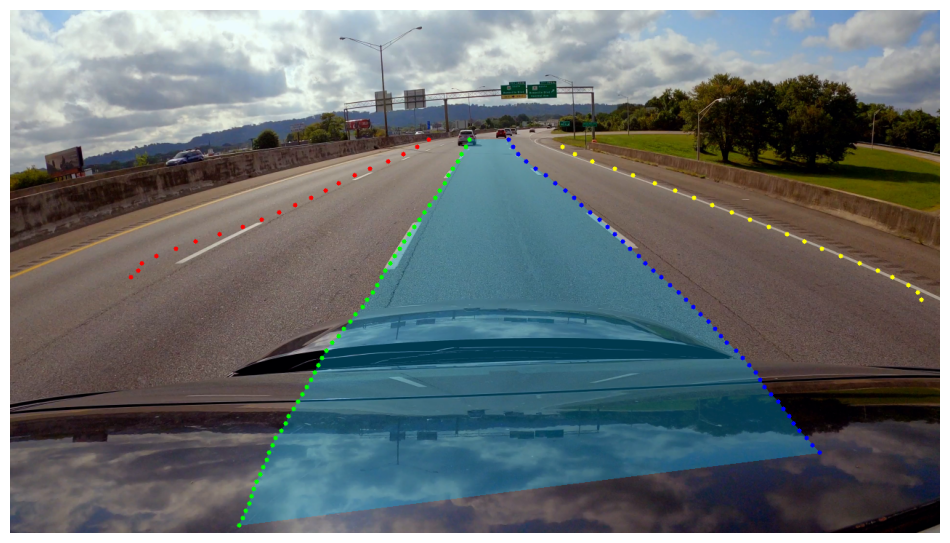

In [3]:
# load the model and test
lane_detector_ufld = UltrafastLaneDetector("/content/Ultrafast-Lane-Detection-Inference-Pytorch-/models/tusimple_18.pth", ModelType.TUSIMPLE, use_gpu=True)

output_img = lane_detector_ufld.detect_lanes(frame)
sv.plot_image(output_img)

In [ ]:
!find / -name "tusimple_18.pth" 2>/dev/null

/content/Ultrafast-Lane-Detection-Inference-Pytorch-/models/tusimple_18.pth


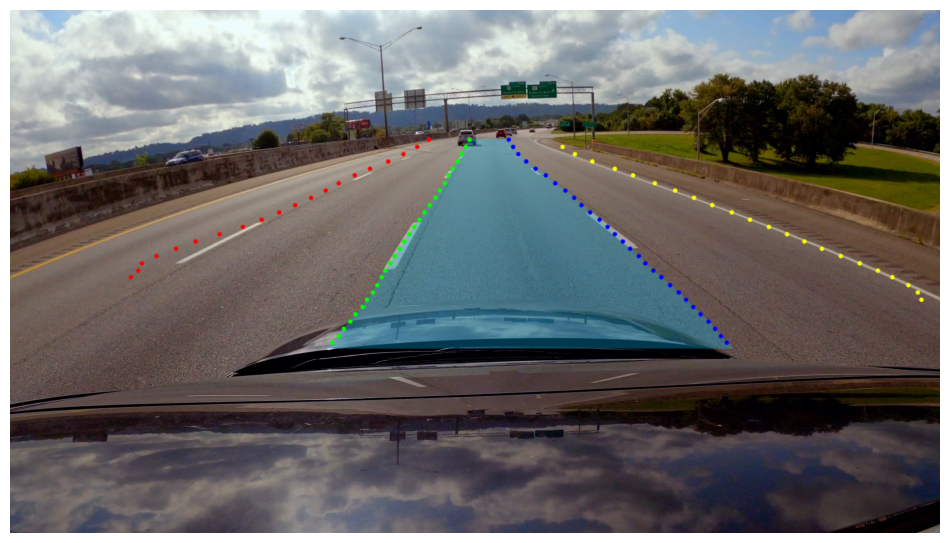

In [5]:
HOOD_Y_START = 1400

output_img = lane_detector_ufld.detect_lanes(frame)

# resize UFLD's output back to original frame dimensions
output_img_resized = cv2.resize(output_img, (frame.shape[1], frame.shape[0]))

# now hood crop works correctly since dimensions match
output_img_resized[HOOD_Y_START:, :] = frame[HOOD_Y_START:, :]

sv.plot_image(output_img_resized)

In [6]:
print(output_img.shape)
print(frame.shape)

(720, 1280, 3)
(2160, 3840, 3)


In [ ]:
from google.colab import files
files.download(TARGET_VIDEO_PATH_FINAL)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
UFLD_FRAME_HEIGHT = 720

**Complete Lane Detection, Vehicle Detection Pipeline**

In [9]:
import cv2
import numpy as np
import supervision as sv
import torch
import math
from tqdm import tqdm
from ultralytics import YOLO
from collections import deque

# ---- config ----
SOURCE_VIDEO_PATH = "5382495-uhd_3840_2160_24fps.mp4"
TARGET_VIDEO_PATH_FINAL = "dashcam-ufld-final-result.mp4"

MODEL_NAME = "yolov8l.pt"
MODEL_RESOLUTION = 1280
CONFIDENCE_THRESHOLD = 0.3
IOU_THRESHOLD = 0.5
VEHICLE_CLASS_IDS = [2, 3, 5, 7]
HOOD_Y_START = 1300
MAX_BOX_WIDTH_PX = 1500

ASSUMED_HORIZONTAL_FOV_DEG = 100
REAL_CAR_WIDTH_M = 1.8

LANE_NAMES = ["Far Left", "Left", "Right", "Far Right"]
UFLD_FRAME_WIDTH = 1280
UFLD_FRAME_HEIGHT = 720

# ---- setup ----
model = YOLO(MODEL_NAME)
video_info = sv.VideoInfo.from_video_path(video_path=SOURCE_VIDEO_PATH)

byte_track = sv.ByteTrack(
    frame_rate=video_info.fps, track_activation_threshold=CONFIDENCE_THRESHOLD
)

thickness = sv.calculate_optimal_line_thickness(resolution_wh=video_info.resolution_wh)
text_scale = sv.calculate_optimal_text_scale(resolution_wh=video_info.resolution_wh)

box_annotator = sv.BoxAnnotator(thickness=thickness)
label_annotator = sv.LabelAnnotator(
    text_scale=text_scale, text_thickness=thickness, text_position=sv.Position.BOTTOM_CENTER
)
trace_annotator = sv.TraceAnnotator(
    thickness=thickness, trace_length=int(video_info.fps * 2), position=sv.Position.BOTTOM_CENTER
)

focal_length_px = (video_info.width / 2) / math.tan(math.radians(ASSUMED_HORIZONTAL_FOV_DEG / 2))

# NEW: a second focal length + camera center, in the UFLD model's own
# 1280x720 coordinate space. Lane points from lane_detector_ufld live in
# THAT space, not the full 3840x2160 frame space - script 1's heading/cte
# math has to be done in the same coordinate space the points are in, or
# the angles come out wrong regardless of the formula being "correct".
FOCAL_LENGTH_PX_UFLD = (UFLD_FRAME_WIDTH / 2) / math.tan(math.radians(ASSUMED_HORIZONTAL_FOV_DEG / 2))
CAMERA_CENTER_X_UFLD = UFLD_FRAME_WIDTH / 2.0
REAL_LANE_WIDTH_M = 3.7
ASSUMED_VELOCITY_MPS = 30.0  # same placeholder script 1 uses

# NEW: script 1's ±2.0 deg cutoff fires on ordinary lane-keeping wobble, not
# just real turns. ENTER is how far the steer has to swing to call it a
# turn; EXIT is how far it has to come back before we call it straight
# again. This is NOT a time-average (still one instantaneous value per
# frame) - it's just two different thresholds depending on current state,
# so a value hovering right at the edge doesn't flicker back and forth.
STEER_ENTER_THRESHOLD_DEG = 6.0
STEER_EXIT_THRESHOLD_DEG = 3.0


def estimate_distance(box_width_px, focal_length_px, real_width_m=REAL_CAR_WIDTH_M):
    if box_width_px <= 0:
        return None
    return (real_width_m * focal_length_px) / box_width_px


# ---- UFLD setup ----
import sys
sys.path.append('/content/Ultrafast-Lane-Detection-Inference-Pytorch-')
from ultrafastLaneDetector import UltrafastLaneDetector, ModelType

lane_detector_ufld = UltrafastLaneDetector(
    "/content/Ultrafast-Lane-Detection-Inference-Pytorch-/models/tusimple_18.pth",
    ModelType.TUSIMPLE,
    use_gpu=True
)

# ---- lane / heading / turn helpers ----


def label_lanes(lanes_points, lanes_detected):
    labels = {}
    for i, (points, detected) in enumerate(zip(lanes_points, lanes_detected)):
        if detected and len(points) > 0:
            labels[LANE_NAMES[i]] = points
    return labels


def smooth_lane_curve(lane_pts, num_samples=60):
    """
    fits a smooth polynomial through the raw UFLD
    points and clips it to the observed x-range.without it, a single noisy detected point at
    the sample y-lines below can swing the heading estimate by many degrees
    and cause turn left/right to false-trigger.
    """
    pts = np.array(lane_pts, dtype=np.float64)
    ys = pts[:, 1]
    xs = pts[:, 0]
    order = np.argsort(ys)
    ys_sorted = ys[order]
    xs_sorted = xs[order]

    y_min, y_max = ys_sorted[0], ys_sorted[-1]
    x_min_obs, x_max_obs = xs_sorted.min(), xs_sorted.max()

    if len(pts) >= 5:
        degree = 2
    elif len(pts) >= 2:
        degree = 1
    else:
        return list(zip(xs_sorted, ys_sorted))

    coeffs = np.polyfit(ys_sorted, xs_sorted, degree)
    y_smooth = np.linspace(y_min, y_max, num_samples)
    x_smooth = np.polyval(coeffs, y_smooth)
    x_smooth = np.clip(x_smooth, x_min_obs, x_max_obs)

    return list(zip(x_smooth, y_smooth))


def lane_anchor_x(points):
    """Average x-position of a lane."""
    xs = [p[0] for p in points]
    return sum(xs) / len(xs)


def pick_left_right_lanes(lanes_points, lanes_detected, frame_width):
    """
    Pick ego lanes as:
      - rightmost lane left of camera center
      - leftmost lane right of camera center
    """
    camera_center = frame_width / 2

    left_candidates = []
    right_candidates = []

    for pts, detected in zip(lanes_points, lanes_detected):
        if not detected or len(pts) < 4:
            continue

        anchor = lane_anchor_x(pts)

        if anchor < camera_center:
            left_candidates.append((anchor, pts))
        else:
            right_candidates.append((anchor, pts))

    left_lane = (
        max(left_candidates, key=lambda x: x[0])[1]
        if left_candidates else None
    )

    right_lane = (
        min(right_candidates, key=lambda x: x[0])[1]
        if right_candidates else None
    )

    return left_lane, right_lane


def compute_stanley_metrics(left_points, right_points, camera_center_x, focal_length_px,
                             lane_width_m=REAL_LANE_WIDTH_M, velocity_m_s=ASSUMED_VELOCITY_MPS):
    """
    THIS IS SCRIPT 1's LOGIC, PORTED DIRECTLY - no history, no smoothing
    window, no hysteresis state machine. Every frame is computed fresh from
    that frame's own smoothed lane curves, exactly like script 1 does:

      - heading error: angle from the camera center to the TOP (farthest
        lookahead) point of the ego lane -> "which way is the road pointing"
      - cte: signed lateral offset from the camera center to the BOTTOM
        (nearest) point of the ego lane, converted to meters using the
        lane's own pixel width -> "how far off-center am I right now"
      - stanley steer: heading_error + atan2(cte, velocity), matching the
        classic Stanley controller script 1 uses
      - direction: "right" if steer > 2 deg, "left" if steer < -2 deg,
        else "straight"

    Returns (heading_error_deg, cte_m, stanley_steer_deg) - direction
    thresholding now happens in the main loop, since it needs the previous
    frame's state to apply hysteresis.
    """
    left_smooth = smooth_lane_curve(left_points)
    right_smooth = smooth_lane_curve(right_points)
    if not left_smooth or not right_smooth:
        return None, None, None

    left_top = min(left_smooth, key=lambda p: p[1])
    right_top = min(right_smooth, key=lambda p: p[1])
    top_center_x = (left_top[0] + right_top[0]) / 2.0
    heading_error_deg = math.degrees(math.atan((top_center_x - camera_center_x) / focal_length_px))

    left_bottom = max(left_smooth, key=lambda p: p[1])
    right_bottom = max(right_smooth, key=lambda p: p[1])
    bottom_center_x = (left_bottom[0] + right_bottom[0]) / 2.0
    lane_width_px = right_bottom[0] - left_bottom[0]

    if lane_width_px <= 0:
        return heading_error_deg, None, None

    meters_per_pixel = lane_width_m / lane_width_px
    cte_m = (bottom_center_x - camera_center_x) * meters_per_pixel

    stanley_steer_deg = heading_error_deg + math.degrees(math.atan2(1.0 * cte_m, velocity_m_s))

    return heading_error_deg, cte_m, stanley_steer_deg


def get_drift_status(cte_m, min_cte_m=0.5):
    """
    Detects lane-position offset using CTE ONLY, independent of heading.
    """
    if cte_m is None:
        return "Unknown"
    if cte_m > min_cte_m:
        return "Drifting Right"
    elif cte_m < -min_cte_m:
        return "Drifting Left"
    else:
        return "Centered"


def draw_text_with_outline(img, text, org, font_scale, color, thickness=3, outline_thickness=6):
    """Draws a black outline behind text for legibility against bright/busy backgrounds."""
    cv2.putText(img, text, org, cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0, 0, 0), outline_thickness, cv2.LINE_AA)
    cv2.putText(img, text, org, cv2.FONT_HERSHEY_SIMPLEX, font_scale, color, thickness, cv2.LINE_AA)


# ---- full loop ----
frame_generator = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH)
frame_index = 0

with sv.VideoSink(TARGET_VIDEO_PATH_FINAL, video_info) as sink:

    for frame in tqdm(frame_generator, total=video_info.total_frames):

        # --- vehicle detection ---
        result = model(frame, imgsz=MODEL_RESOLUTION, verbose=False)[0]
        detections = sv.Detections.from_ultralytics(result)

        detections = detections[detections.confidence > CONFIDENCE_THRESHOLD]
        detections = detections[np.isin(detections.class_id, VEHICLE_CLASS_IDS)]
        detections = detections[detections.xyxy[:, 3] < HOOD_Y_START]

        # NEW: same max box-width sanity check as script 1 (drops absurdly
        # wide / too-close-to-camera boxes that are usually detection noise)
        box_widths_all = detections.xyxy[:, 2] - detections.xyxy[:, 0]
        detections = detections[box_widths_all < MAX_BOX_WIDTH_PX]

        detections = detections.with_nms(IOU_THRESHOLD)

        # --- tracking ---
        detections = byte_track.update_with_detections(detections=detections)

        # --- distance estimation ---
        box_widths = detections.xyxy[:, 2] - detections.xyxy[:, 0]
        distances = [estimate_distance(w, focal_length_px) for w in box_widths]
        labels = [
            f"#{tid} {dist:.1f}m" if dist is not None else f"#{tid}"
            for tid, dist in zip(detections.tracker_id, distances)
        ]

        # --- lane detection (UFLD) ---
        lane_output = lane_detector_ufld.detect_lanes(frame)

        annotated_frame = cv2.resize(lane_output, (frame.shape[1], frame.shape[0]))
        annotated_frame[HOOD_Y_START:, :] = frame[HOOD_Y_START:, :]

        # --- lane labeling + heading/turn detection ---
        lane_labels = label_lanes(lane_detector_ufld.lanes_points, lane_detector_ufld.lanes_detected)

        lanes_detected = lane_detector_ufld.lanes_detected
        lanes_points = lane_detector_ufld.lanes_points

        # --- DEBUG: log slot detection/position during turns ---
        if 200 <= frame_index <= 460:
            print(f"frame {frame_index}: detected={lanes_detected}, "
                  f"slot0_x={lanes_points[0][-1][0] if lanes_detected[0] and len(lanes_points[0]) else None}, "
                  f"slot1_x={lanes_points[1][-1][0] if lanes_detected[1] and len(lanes_points[1]) else None}, "
                  f"slot2_x={lanes_points[2][-1][0] if lanes_detected[2] and len(lanes_points[2]) else None}, "
                  f"slot3_x={lanes_points[3][-1][0] if lanes_detected[3] and len(lanes_points[3]) else None}")
        # FIXED: this now always increments, instead of only inside the
        # debug `if` block above (which meant frame_index was permanently
        # stuck at 0 and the debug block above could never fire).
        frame_index += 1

        # runs every frame, unconditionally
        left_pts, right_pts = pick_left_right_lanes(
            lanes_points,
            lanes_detected,
            UFLD_FRAME_WIDTH
        )

        heading_error_corrected, cte_m, stanley_steer = (None, None, None)
        if left_pts is not None and right_pts is not None:
            heading_error_corrected, cte_m, stanley_steer = compute_stanley_metrics(
                left_pts, right_pts, CAMERA_CENTER_X_UFLD, FOCAL_LENGTH_PX_UFLD
            )

        last_direction = getattr(compute_stanley_metrics, "_last_direction", "straight")

        if stanley_steer is None:
            # Lanes not detected this frame - hold last known direction
            # rather than flashing "N/A" every time detection drops out.
            direction = last_direction
        elif last_direction == "straight":
            # Not currently turning: need the wider ENTER threshold to
            # start counting this as a turn.
            if stanley_steer > STEER_ENTER_THRESHOLD_DEG:
                direction = "right"
            elif stanley_steer < -STEER_ENTER_THRESHOLD_DEG:
                direction = "left"
            else:
                direction = "straight"
        else:
            # Currently turning: only need to drop back inside the
            # narrower EXIT threshold to call it straight again. Still
            # allows an immediate flip straight to the opposite direction
            # if the steer swings hard the other way.
            if stanley_steer > STEER_ENTER_THRESHOLD_DEG:
                direction = "right"
            elif stanley_steer < -STEER_ENTER_THRESHOLD_DEG:
                direction = "left"
            elif last_direction == "left" and stanley_steer > -STEER_EXIT_THRESHOLD_DEG:
                direction = "straight"
            elif last_direction == "right" and stanley_steer < STEER_EXIT_THRESHOLD_DEG:
                direction = "straight"
            else:
                direction = last_direction

        compute_stanley_metrics._last_direction = direction

        if direction == "left":
            turn_status = "Turning Left"
        elif direction == "right":
            turn_status = "Turning Right"
        else:
            turn_status = "Straight"

        drift_status = get_drift_status(cte_m)

        scale_x = frame.shape[1] / UFLD_FRAME_WIDTH
        scale_y = frame.shape[0] / UFLD_FRAME_HEIGHT

        # --- diagnostic text block, top-left ---
        info_lines = [
            f"heading err (deg): {heading_error_corrected:.2f}" if heading_error_corrected is not None else "heading err (deg): N/A",
            f"cte (m): {cte_m:.2f}" if cte_m is not None else "cte (m): N/A",
            f"stanley steer (deg): {stanley_steer:.2f}" if stanley_steer is not None else "stanley steer (deg): N/A",
            f"road: {turn_status}",
            f"lane position: {drift_status}",
        ]
        y0 = 60
        for i, line in enumerate(info_lines):
            draw_text_with_outline(
                annotated_frame, line, (20, y0 + i * 55),
                font_scale=1.4, color=(0, 255, 255), thickness=3, outline_thickness=7
            )

        # --- lane labels positioned along the lane lines, not on hood ---
        for name, points in lane_labels.items():
            if len(points) == 0:
                continue
            idx = min(len(points) - 1, len(points) // 3)
            x, y = points[idx]
            x_scaled, y_scaled = int(x * scale_x), int(y * scale_y)

            if name == "Left":
                display_name = "EGO-L"
            elif name == "Right":
                display_name = "EGO-R"
            else:
                display_name = name

            draw_text_with_outline(
                annotated_frame, display_name, (x_scaled, y_scaled),
                font_scale=1.6, color=(0, 255, 0), thickness=3, outline_thickness=7
            )

        # --- draw vehicle detections on top ---
        annotated_frame = trace_annotator.annotate(scene=annotated_frame, detections=detections)
        annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)
        annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections, labels=labels)

        sink.write_frame(annotated_frame)

 25%|██▍       | 201/818 [01:09<03:10,  3.23it/s]

frame 200: detected=[ True  True  True  True], slot0_x=521, slot1_x=595, slot2_x=650, slot3_x=718


 25%|██▍       | 202/818 [01:09<03:10,  3.24it/s]

frame 201: detected=[ True  True  True  True], slot0_x=521, slot1_x=595, slot2_x=649, slot3_x=714


 25%|██▍       | 203/818 [01:10<03:08,  3.27it/s]

...

 56%|█████▌    | 460/818 [02:35<01:48,  3.30it/s]

frame 459: detected=[ True  True  True  True], slot0_x=466, slot1_x=545, slot2_x=601, slot3_x=668


 56%|█████▋    | 461/818 [02:35<01:49,  3.27it/s]

frame 460: detected=[ True  True  True  True], slot0_x=470, slot1_x=547, slot2_x=605, slot3_x=684


100%|██████████| 818/818 [04:33<00:00,  2.99it/s]
